# WIMP Dark Matter in Alternative Cosmologies - Jacobian normalization

## Imports

In [1]:
import torch
from torch.optim.lr_scheduler import ExponentialLR
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

from pinn import PINN
import utils

## Constants

In [2]:
z0 = utils.Z0
zf = utils.ZF

g = utils.G
g_asts = utils.G_ASTS

w0 = utils.W0
wf = utils.WF

w_n = -wf

C_std = utils.C_STD

zt1 = utils.ZT1

num_coloc = 1000 # To compare solve_ivp with the PINN, we need the same number of points in both, so we define it here.

## Finite element method 

In [3]:
def w_eq_fem(z):
    """
    Computes the equilibrium yield W_eq for the finite element method.

    Parameters:
        z (float): The logarithm of x = m_DM / T.
        
    Returns:
        float: The definition of W_eq.
    """
    
    return np.log(45.0 / np.sqrt(32.0 * np.pi**7) * g / g_asts) + 1.5 * z - np.exp(z)

In [4]:
def returns_dwdz(z, w, C): 
    """
    Computes the derivative of the Boltzmann equation for comparison purposes.

    Parameters:
        z (float): The logarithm of x = m_DM / T.
        w (float): The logarithm of Y, the number density of DM.
        C (float): Proxy for the cross-section.
        
    Returns:
        float: The derivative of the Boltzmann equation.
    """
    dwdz = np.exp(C - z) * (np.exp(2.0 * w_eq_fem(z) - w) - np.exp(w)) # Standard cosmology (gamma=0) is always assumed here.
        
    return dwdz
  
# Time
z = np.linspace(z0, zf, num_coloc) 
  
# ODE solver
fem_sol = solve_ivp(returns_dwdz, [z0, zf], np.array([w0]), method='BDF', t_eval=z, args=(C_std,), dense_output=True, rtol=1e-7, atol=1e-9) # Change C_std here to test other cross sections

## Plotting function (for training)

In [5]:
def plotting(C, preds, x_coloc):
    """
    Plots the PINN and FEM solutions of the ODE.

    Parameters:
        C (float): Proxy for the cross-section.
        preds (float): Predictions of the PINN.
        x_coloc (float): Collocation points.
    """

    x_coloc = x_coloc.detach().numpy()
    
    plt.figure(figsize=(10,8))
    plt.plot(x_coloc, preds, 'r', label='PINN')
    plt.plot(fem_sol.t, fem_sol.y.reshape(-1,) / w_n, color='green', linestyle=':', label='Exact solution')
    plt.xlabel(r'$z$') 
    plt.ylabel(r'$W_n$') 
    plt.legend()
    plt.show()

In [6]:
print(fem_sol.y[-1][-1]) # Important to make comparisons between the result provided by the PINN and the one provided by solve_ivp

-26.158508777959046


### W_eq definition for PyTorch

In [7]:
def w_eq(z):
    """
    Computes the equilibrium yield W_eq for PyTorch.

    Parameters:
        z (float): The logarithm of x = m_DM / T.
        
    Returns:
        float: The definition of W_eq.
    """
    return torch.log(45.0 / torch.sqrt(torch.tensor(32.0 * np.pi**7)) * g / g_asts) + 1.5 * z - torch.exp(z)

### Training step

In [8]:
normalize_jacobian = False

n_tries = 1 # For the ablation test, this must be > 1
n_epochs = 200_000
lr = 1.0e-3
output_sigmoid = True

# Collocation points
z_co = np.linspace(z0, zf, num_coloc)
z_co = torch.tensor(z_co, dtype=torch.float32).view(-1, 1).requires_grad_(True)

# C parameter
C = torch.tensor(C_std, requires_grad=False)

In [9]:
def make_loss(C, normalize_jac):
    def pinn_loss(self, x):
            
        x = x.clone().detach().requires_grad_(True)

        # Forward pass
        w = self.forward(x)

        # dy/dx via autograd
        dw_z = torch.autograd.grad(
            outputs=w,
            inputs=x,
            grad_outputs=torch.ones_like(w),
            create_graph=True,
            retain_graph=True
        )[0]

        lhs = dw_z * w_n 
        rhs = torch.exp(C - z_co) * (torch.exp(2 * w_eq(z_co) - w * w_n) - torch.exp(w * w_n))

        # Absolute jacobian (which will normalize the residuals)
        jacobian = torch.exp(C - z_co) * (torch.exp(2 * w_eq(z_co) - w * w_n) + torch.exp(w * w_n)) # Since the exponentials are always positive, we just remove the global minus sign to obtain the absolute value

        residual = (lhs - rhs)
        ode_loss = torch.mean(residual**2 / (1.0 + normalize_jac * jacobian**2))
        x0_loss = torch.square(w[0] - w0 / w_n)

        total_loss = ode_loss + x0_loss
        
        return ode_loss, x0_loss, total_loss
    return pinn_loss

In [10]:
def training(n_epochs, C):
    
    print("-----------------------------------------")
    print(f"Running for C = {C}")
    print("-----------------------------------------")

    loss_fn = make_loss(C, normalize_jacobian)
    model = PINN(40, 4, 1, lr, loss_fn, output_sigmoid=output_sigmoid)
    scheduler = ExponentialLR(model.optimizer, gamma=0.99)
    fem_sol_torch = torch.tensor(fem_sol.y, dtype=torch.float32)
    PINNvsFEM = []

    best_loss = 1.0e30
    
    for epoch in range(int(n_epochs)):
        losses = model.train_step(z_co)
        preds = model.predict(z_co)
        PINNvsFEM.append(torch.mean(torch.square((torch.squeeze(preds) - fem_sol_torch / w_n) / (fem_sol_torch /  w_n))))
        if epoch % 1000 == 0:
            scheduler.step()
        if epoch % 10000 == 0:
            print(f"Epoch {epoch:3d} | Best: {best_loss:.6f} | Total: {losses['total_loss']:.6f} | ODE: {losses['ode_loss']:.6f} | IC: {losses['x0_loss']:.6f}")
    
        if losses['total_loss'] < best_loss and epoch != 0: 
            torch.save(model.state_dict(), './dataFreezeOut/best-FwdStd-norm' + str(normalize_jacobian) + '-Sigmoid' + str(output_sigmoid) + str(int(np.floor(C))) + '.pt')
            best_loss = losses['total_loss']
    
    best_model = PINN(40, 4, 1, lr, loss_fn, output_sigmoid=output_sigmoid)
    best_model.load_state_dict(torch.load('./dataFreezeOut/best-FwdStd-norm' + str(normalize_jacobian) + '-Sigmoid' + str(output_sigmoid) + str(int(np.floor(C))) + '.pt'))
    
    preds = best_model.predict(z_co)
    best_PINNvsFEM = torch.square((torch.squeeze(preds) - fem_sol_torch / w_n) / (fem_sol_torch / w_n))

    np.savetxt("dataFreezeOut/PINNvsFEM-norm" + str(normalize_jacobian) + "-Sigmoid" + str(output_sigmoid) + ".txt", PINNvsFEM) # Only done for the cross section that predicts the observed relic density (comment if C != C_std)
    plotting(C, preds, z_co)

    return best_PINNvsFEM

-----------------------------------------
Running for C = 29.203699111938477
-----------------------------------------
Epoch   0 | Best: 1000000000000000019884624838656.000000 | Total: 6724570049806579269632.000000 | ODE: 6724570049806579269632.000000 | IC: 0.036200


/tmp/ipykernel_14541/1400663281.py:25: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  torch.save(model.state_dict(), './dataFreezeOut/best-FwdStd-norm' + str(normalize_jacobian) + '-Sigmoid' + str(output_sigmoid) + str(int(np.floor(C))) + '.pt')


Epoch 10000 | Best: 233935426551808.000000 | Total: 233767939604480.000000 | ODE: 233767939604480.000000 | IC: 0.000000
Epoch 20000 | Best: 2399602999296.000000 | Total: 2427316338688.000000 | ODE: 2427316338688.000000 | IC: 0.000000
Epoch 30000 | Best: 183489134592.000000 | Total: 523299848192.000000 | ODE: 523299848192.000000 | IC: 0.000000
Epoch 40000 | Best: 20799735808.000000 | Total: 20982300672.000000 | ODE: 20982300672.000000 | IC: 0.000000
Epoch 50000 | Best: 11002012672.000000 | Total: 1721474482176.000000 | ODE: 1721474482176.000000 | IC: 0.000000
Epoch 60000 | Best: 5472636416.000000 | Total: 16877239664640.000000 | ODE: 16877239664640.000000 | IC: 0.000000
Epoch 70000 | Best: 2892657920.000000 | Total: 422256705536.000000 | ODE: 422256705536.000000 | IC: 0.000000
Epoch 80000 | Best: 1988355584.000000 | Total: 2360163072.000000 | ODE: 2360163072.000000 | IC: 0.000000
Epoch 90000 | Best: 1670308480.000000 | Total: 490625269760.000000 | ODE: 490625269760.000000 | IC: 0.000000

/tmp/ipykernel_14541/1400663281.py:29: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  best_model.load_state_dict(torch.load('./dataFreezeOut/best-FwdStd-norm' + str(normalize_jacobian) + '-Sigmoid' + str(output_sigmoid) + str(int(np.floor(C))) + '.pt'))


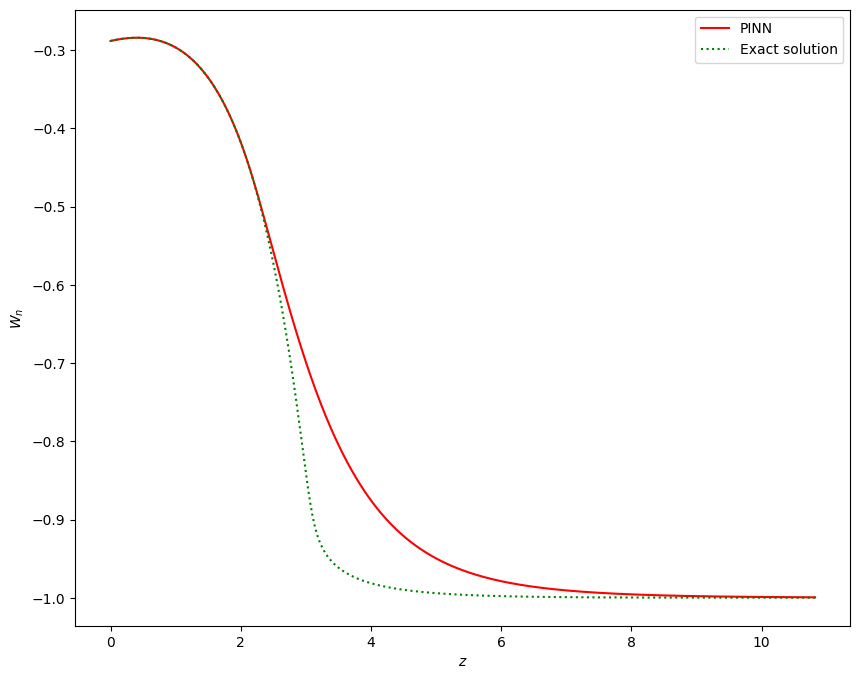

In [11]:
output_preds = []
    
for _ in range(n_tries):
    output_preds.append(training(n_epochs, C))

if n_tries > 1:
    output_preds = np.array(output_preds).reshape(n_tries, -1)
    np.savetxt('dataFreezeOut/AblationTest-norm' + str(normalize_jacobian) + '-Sigmoid' + str(output_sigmoid) + '.txt', output_preds)